In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift
from scipy.special import eval_jacobi
from skimage.draw import disk, ellipse
import pandas as pd
from PIL import Image
import json
import importlib
import modulesDataSet as mds
import os
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

importlib.reload(mds)



datasetDirectory = './dataset'
os.makedirs(datasetDirectory, exist_ok=True)
print("Папка dataset создана")


phases, coeffs, poly_list = mds.generate_chebyshev_dataset(num_samples=1, size=256, max_order=7, seed=0)


print("Информация о генерируемой фазе:")
print("- Размер массива:", phases.shape)        # (1, 256, 256)
print("- Размер массива с коэффициентами:", coeffs.shape)  # (1, 36)
print("- Первые 7 полиномов:", poly_list[:7])

#plt.imshow(phases[0], cmap='twilight')
#plt.colorbar()
#plt.title('фактическое')
#plt.show()

Using device: cuda
Папка dataset создана
Информация о генерируемой фазе:
- Размер массива: (1, 256, 256)
- Размер массива с коэффициентами: (1, 36)
- Первые 7 полиномов: [(0, 0), (0, 1), (1, 0), (0, 2), (1, 1), (2, 0), (0, 3)]


Сгенерирован массив амплитуд размером (10, 256, 256)
Параметры первого примера: {'mode': np.str_('uniform')}
Параметры пятого примера: {'mode': np.str_('gaussian'), 'center_x': 99, 'center_y': 78, 'sigma': 135.90444580958814, 'amplitude_max': 0.9909729556485982}


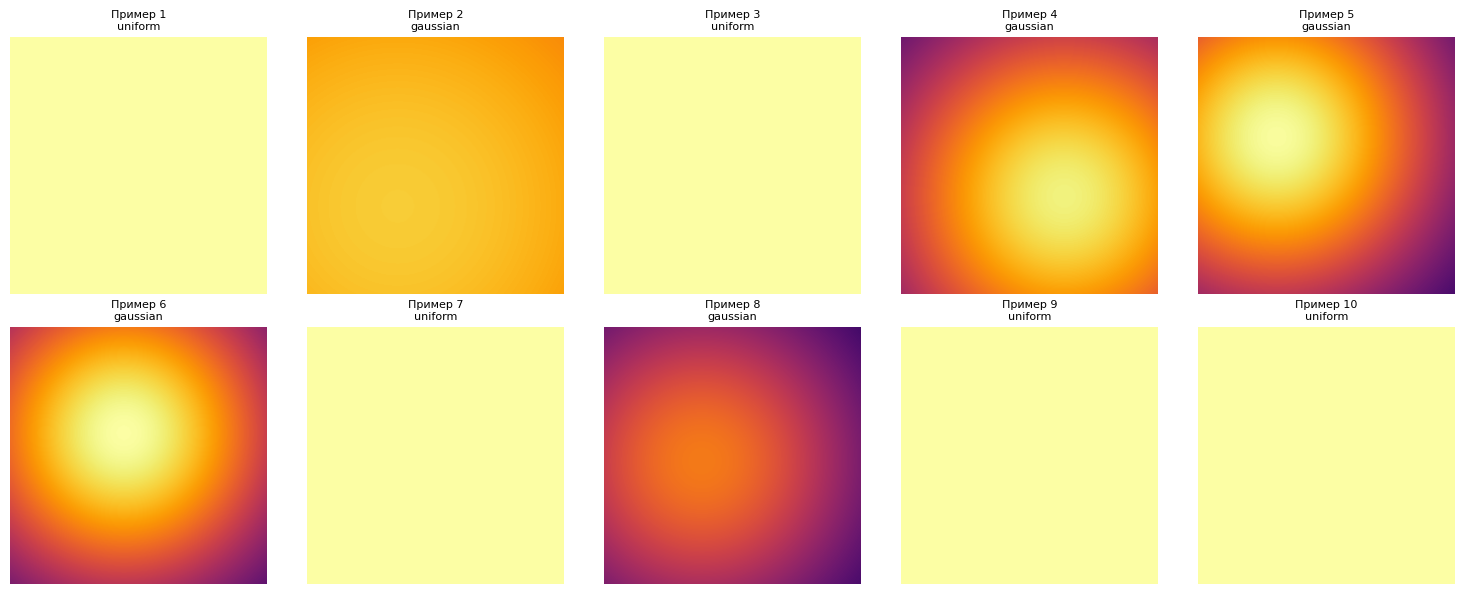


Распределение режимов в выборке: {np.str_('uniform'): 5, np.str_('gaussian'): 5}


In [38]:
if __name__ == "__main__":
    # Генерируем 10 амплитуд размером 256x256
    num_samples = 10
    amps, params = mds.generate_amplitude_dataset(num_samples=num_samples, size=256, seed=42)

    print(f"Сгенерирован массив амплитуд размером {amps.shape}")  # (10, 256, 256)
    print("Параметры первого примера:", params[0])
    print("Параметры пятого примера:", params[4])

    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            im = ax.imshow(amps[i], cmap='inferno', vmin=0, vmax=1)
            ax.set_title(f"Пример {i+1}\n{params[i]['mode']}", fontsize=8)
            ax.axis('off')
    plt.tight_layout()
    #fig.set_facecolor("#9EB4C5")
    #plt.savefig('amplitude_samples.png', dpi=150)
    plt.show()

    
    modes_count = {}
    for p in params:
        m = p['mode']
        modes_count[m] = modes_count.get(m, 0) + 1
    print("\nРаспределение режимов в выборке:", modes_count)

In [ ]:
"""
Создание набора пучков. 

Для создания 80000 пучков требуется ~9 минут. Вычисления на CPU Ryzen 5 5600X, RAM 4x8 GB
batch_size подбирать исходя из доступной оперативной памяти,

"""


os.makedirs(datasetDirectory + '/beams', exist_ok=True) #Папка beams для пучков
print("Папка dataset/beams создана")

numSamples = 80000
batch_size = 1000          # 1000-2000 оптимальный

metadata = []            

# Генерация батчами
for start in range(0, numSamples, batch_size):
    end = min(start + batch_size, numSamples)
    batch_count = end - start

    # Генерируем фазы и коэффициенты Чебышева для текущего батча
    phases_batch, coeffs_batch, poly_list = mds.generate_chebyshev_dataset(
        num_samples=batch_count,
        size=256,
        max_order=7,
        seed=start          # разный seed для каждого батча → разные образцы
    )

    # Генерируем амплитуды для того же батча
    amps_batch, amp_params = mds.generate_amplitude_dataset(
        num_samples=batch_count,
        size=256,
        seed=start
    )

    # Обрабатываем каждый образец в батче
    for j in range(batch_count):
        idx = start + j
        amp = amps_batch[j]          # (256, 256) float [0, 1]
        phase = phases_batch[j]      # (256, 256) float [-π, π]

        # нормируем в 8-битный диапазон
        amp_uint8 = (amp * 255).astype(np.uint8)
        phase_uint8 = ((phase + np.pi) / (2 * np.pi) * 255).astype(np.uint8)

        # R - амплитуда, G - фаза, B = 0
        img_rgb = np.stack([amp_uint8, phase_uint8, np.zeros_like(amp_uint8)], axis=-1)

        # сохранение png 
        filename = f'beam_{idx:06d}.png'
        img_pil = Image.fromarray(img_rgb, mode='RGB')
        img_pil.save(os.path.join(datasetDirectory, 'beams', filename))

        #  словарь коэффициентов Чебышева для метаданных
        cheb_dict = {}
        for k, (p, q) in enumerate(poly_list):
            key = f"{p}_{q}"
            cheb_dict[key] = float(coeffs_batch[j][k])

        metadata.append({
            "filename": filename,
            "chebyshev_coefficients": cheb_dict
        })
        
    print('Сгенерировано ', end, '/', numSamples)
    # Освобождаем память после обработки батча
    del phases_batch, coeffs_batch, amps_batch, amp_params

# Сохраняем метаданные в корневой каталог
with open(os.path.join(datasetDirectory, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Сохранено {numSamples} изображений в {os.path.join(datasetDirectory, 'beams')}")
print(f"Метаданные сохранены в {os.path.join(datasetDirectory, 'metadata.json')}")

Папка dataset/beams создана


C:\Users\thatm\AppData\Local\Temp\ipykernel_30432\2515709410.py:53: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_pil = Image.fromarray(img_rgb, mode='RGB')


Сгенерировано  1000 / 80000
Сгенерировано  2000 / 80000
Сгенерировано  3000 / 80000
Сгенерировано  4000 / 80000
Сгенерировано  5000 / 80000
Сгенерировано  6000 / 80000
Сгенерировано  7000 / 80000
Сгенерировано  8000 / 80000
Сгенерировано  9000 / 80000
Сгенерировано  10000 / 80000
Сгенерировано  11000 / 80000
Сгенерировано  12000 / 80000
Сгенерировано  13000 / 80000
Сгенерировано  14000 / 80000
Сгенерировано  15000 / 80000
Сгенерировано  16000 / 80000
Сгенерировано  17000 / 80000
Сгенерировано  18000 / 80000
Сгенерировано  19000 / 80000
Сгенерировано  20000 / 80000
Сгенерировано  21000 / 80000
Сгенерировано  22000 / 80000
Сгенерировано  23000 / 80000
Сгенерировано  24000 / 80000
Сгенерировано  25000 / 80000
Сгенерировано  26000 / 80000
Сгенерировано  27000 / 80000
Сгенерировано  28000 / 80000
Сгенерировано  29000 / 80000
Сгенерировано  30000 / 80000
Сгенерировано  31000 / 80000
Сгенерировано  32000 / 80000
Сгенерировано  33000 / 80000
Сгенерировано  34000 / 80000
Сгенерировано  35000 / 

In [51]:
#Генерация маски от 0 до 128. Это соответсвует от 0 до pi. Маски одни и те же, для контроля
import numpy as np
from PIL import Image
import os
os.makedirs(datasetDirectory + '/masks', exist_ok=True)
folder = datasetDirectory + '/masks/'

for i in range (3):
  np.random.seed(0+i)
  random_matrix = np.random.randint(0, 128, (256, 256), dtype=np.uint8)
  img_original = Image.fromarray(random_matrix, mode='L')
  #img_upscaled = img_original.resize((256, 256), Image.NEAREST)
  img_upscaled_real = img_original.resize((1024, 1024), Image.NEAREST)
  img_original.save(folder + str(i) + 'mask256.png')
  img_upscaled_real.save(folder + str(i) + 'mask1024.png')

# mask256 - для обучения, маск1024 - для вывода на ПВМС

C:\Users\thatm\AppData\Local\Temp\ipykernel_30432\488435354.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_original = Image.fromarray(random_matrix, mode='L')


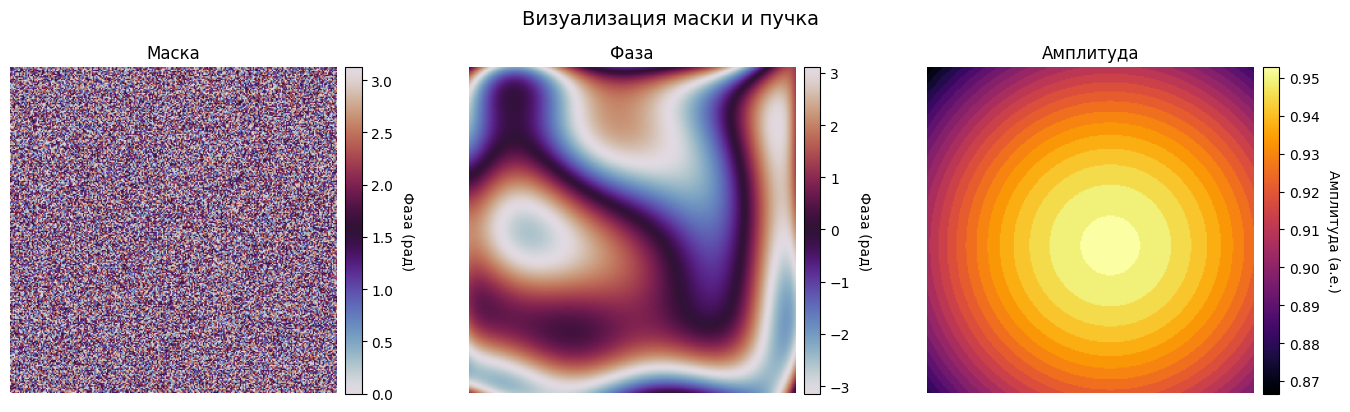

In [52]:
""" Проверяем, что изображения открываются
"""
importlib.reload(mds)


phase_mask = mds.load_mask_info(0, folder_path=datasetDirectory + '/masks', device='cuda')
amp, phase = mds.load_beam_info_image(1, folder_path=datasetDirectory + '/beams', device='cuda')


# обратно в нампай для визуализации

phase_mask = phase_mask.detach().cpu().numpy()
amp = amp.detach().cpu().numpy()
phase = phase.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=100)
fig.suptitle(f'Визуализация маски и пучка', fontsize=14, y=1.02)


im0 = axes[0].imshow(phase_mask, cmap='twilight')
axes[0].set_title('Маска')
axes[0].axis('off')  # убираем рамки для чистоты
cbar0 = plt.colorbar(im0, ax=axes[0], pad=0.02)
cbar0.set_label('Фаза (рад)', rotation=270, labelpad=15)


im1 = axes[1].imshow(phase, cmap='twilight')
axes[1].set_title('Фаза')
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], pad=0.02)
cbar1.set_label('Фаза (рад)', rotation=270, labelpad=15)


im2 = axes[2].imshow(amp, cmap='inferno')
axes[2].set_title('Амплитуда')
axes[2].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[2], pad=0.02)
cbar2.set_label('Амплитуда (а.е.)', rotation=270, labelpad=15)

# Автоматическая подгонка расположения
plt.tight_layout()
plt.show()

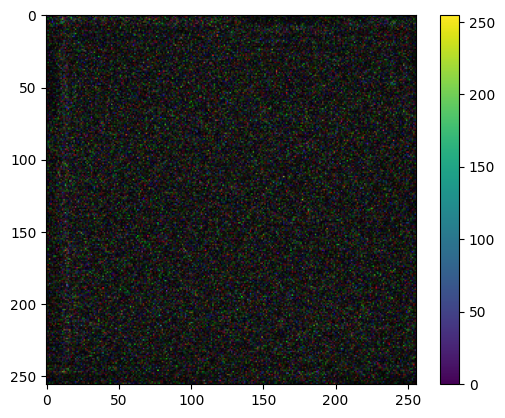

In [53]:
"""
Для отладки: рассчитываем трехканальную картину дифракции

"""
importlib.reload(mds)

# Константы
lam = 532e-9
z = 0.200  # м
pixelsizeSLM = 32e-6  # м

def difraction(i, device='cuda'):
    """
    Расчёт трёхканального изображения дифракции.
    Возвращает тензор (H, W, 3) типа uint8, готовый для отображения.
    """
    # 1. Загружаем амплитуду и фазу пучка (тензоры на device)
    amp, phase = mds.load_beam_info_image(i, folder_path=datasetDirectory + '/beams', device=device)

    # 2. Загружаем маски для всех трёх каналов (стек)
    masks = torch.stack([mds.load_mask_info(k, folder_path=datasetDirectory + '/masks',device=device) for k in range(3)], dim=0)  # (3, 256, 256)

    # 3. Расширяем amp и phase для broadcasting на 3 канала
    amp_3ch = amp.unsqueeze(0).expand(3, -1, -1)          # (3, 256, 256)
    phase_3ch = phase.unsqueeze(0).expand(3, -1, -1)

    # 4. Комплексное поле на входе (все каналы сразу)
    E0 = amp_3ch * torch.exp(1j * (phase_3ch + masks))   # (3, 256, 256) комплексный

    # 5. Дифракция (пропагатор + детектор) для всех каналов
    # FresnelPropagator и detectCamera уже работают с тензорами и поддерживают пакетную обработку
    propagated = mds.FresnelPropagator(E0, pixelsizeSLM, lam, z, device=device)  # (3, 256, 256) комплексный
    intensity = mds.detectCamera(propagated)  # (3, 256, 256) float

    # 6. Нормировка каждого канала на максимум и приведение к uint8
    # Найдём максимум для каждого канала отдельно (по пространственным измерениям)
    max_per_channel = intensity.view(3, -1).max(dim=1, keepdim=True)[0].view(3, 1, 1)  # (3, 1, 1)
    # Защита от деления на ноль
    max_per_channel = torch.where(max_per_channel == 0, torch.ones_like(max_per_channel), max_per_channel)
    intensity_norm = intensity / max_per_channel * 255   # (3, 256, 256) float

    # Приводим к uint8
    intensity_uint8 = intensity_norm.to(torch.uint8)     # (3, 256, 256)

    # 7. Переставляем оси в формат (H, W, 3) для визуализации и возврата
    img_tensor = intensity_uint8.permute(1, 2, 0)        # (256, 256, 3)

    return img_tensor

# Пример использования
difracted3channel = difraction(4, device='cuda')  # если GPU нет, укажите device='cpu'

# Визуализация (переводим в numpy)
plt.imshow(difracted3channel.cpu().numpy())
plt.colorbar()
plt.show()

In [ ]:
"""
Рассчитываем трехканальные картины дифракции.

Расчёт на GeForce RTX 4070 Super занимает порядка ~11 минут

"""
import os
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
importlib.reload(mds)

# Создаём папку
os.makedirs(datasetDirectory + '/difracted_beams', exist_ok=True)
print('Папка dataset/difracted_beams создана')

# Загружаем маски один раз (3 канала) и переносим на GPU
masks = torch.stack([mds.load_mask_info(k, device='cuda', folder_path=datasetDirectory + '/masks') for k in range(3)], dim=0)  # (3, 256, 256)

num_samples = 80000 # Проверить, что соответсвует пучкам. На всякий сделал отдельной переменной 
batch_size = 500   # оптимально 500 под размер GPU

# Пул потоков для сохранения
executor = ThreadPoolExecutor(max_workers=4)

# Список для хранения будущих задач (чтобы дождаться завершения)
futures = []

for start in range(0, num_samples, batch_size):
    end = min(start + batch_size, num_samples)
    indices = list(range(start, end))

    # Генерируем батч изображений (тензор на GPU)
    img_batch = mds.difraction_batch(indices, masks, device='cuda', folder_path=datasetDirectory + '/beams')  # (B, H, W, 3) uint8

    # Отправляем каждое изображение на сохранение в отдельном потоке
    for j, idx in enumerate(indices):
        filename = f'difracted_beam_{idx:06d}.png'
        save_path = os.path.join(datasetDirectory, 'difracted_beams', filename)
        # imageio.imwrite тоже подойдёт, но Pillow требует перестановки осей (уже (H,W,3))
        img_np = img_batch[j].cpu().numpy()  # (H, W, 3) uint8
        future = executor.submit(Image.fromarray, img_np, 'RGB')  # создаёт объект Image
        # сохраняем через метод save
        future = executor.submit(lambda p=save_path, img=img_np: Image.fromarray(img, 'RGB').save(p))
        futures.append(future)

    # Освобождаем память от батча (если нужно)
    del img_batch

    # Прогресс
    print(f"Сгенерировано {end}/{num_samples} samples")

# Дожидаемся завершения всех сохранений
for f in futures:
    f.result()

print("Генерация завершена")


Папка dataset/difracted_beams создана


C:\Users\thatm\AppData\Local\Temp\ipykernel_30432\47933078.py:41: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  future = executor.submit(lambda p=save_path, img=img_np: Image.fromarray(img, 'RGB').save(p))


Сгенерировано 500/80000 samples
Сгенерировано 1000/80000 samples
Сгенерировано 1500/80000 samples
Сгенерировано 2000/80000 samples
Сгенерировано 2500/80000 samples
Сгенерировано 3000/80000 samples
Сгенерировано 3500/80000 samples
Сгенерировано 4000/80000 samples
Сгенерировано 4500/80000 samples
Сгенерировано 5000/80000 samples
Сгенерировано 5500/80000 samples
Сгенерировано 6000/80000 samples
Сгенерировано 6500/80000 samples
Сгенерировано 7000/80000 samples
Сгенерировано 7500/80000 samples
Сгенерировано 8000/80000 samples
Сгенерировано 8500/80000 samples
Сгенерировано 9000/80000 samples
Сгенерировано 9500/80000 samples
Сгенерировано 10000/80000 samples
Сгенерировано 10500/80000 samples
Сгенерировано 11000/80000 samples
Сгенерировано 11500/80000 samples
Сгенерировано 12000/80000 samples
Сгенерировано 12500/80000 samples
Сгенерировано 13000/80000 samples
Сгенерировано 13500/80000 samples
Сгенерировано 14000/80000 samples
Сгенерировано 14500/80000 samples
Сгенерировано 15000/80000 samples
